In [ ]:
!pip install transformers peft datasets accelerate bitsandbytes faiss-cpu sentence-transformers

  Using cached faiss_cpu-1.13.2-cp310-abi3-macosx_14_0_arm64.whl.metadata (7.6 kB)
  Using cached sentence_transformers-5.4.1-py3-none-any.whl.metadata (17 kB)
Using cached faiss_cpu-1.13.2-cp310-abi3-macosx_14_0_arm64.whl (3.5 MB)
Using cached sentence_transformers-5.4.1-py3-none-any.whl (571 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [sentence-transformers]ence-transformers]


GPU check

In [ ]:
import torch
import matplotlib.pyplot as plt
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    TrainingArguments, Trainer, TrainerCallback,
    DataCollatorForLanguageModeling, EarlyStoppingCallback
)
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset

# Confirm GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if device == 'cuda' else 'None'}")

Using device: cuda
GPU: Tesla T4


Load model and tokenizer

In [ ]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token  # required for batching

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,  # saves VRAM
    device_map="auto"           # auto-places on GPU
)
print(f"Model loaded. Parameters: {model.num_parameters():,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model loaded. Parameters: 1,100,048,384


Apply LoRA

In [ ]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,                        # rank — keep low for Colab
    lora_alpha=16,              # scaling factor
    lora_dropout=0.1,           # regularization (dropout)
    target_modules=["q_proj", "v_proj"],  # which layers to adapt
    bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# Expect ~0.1% of params trainable — that's normal and correct

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


Load & Format Dataset (SFT / Instruction Tuning)

In [ ]:
# Load Alpaca-style instruction dataset
dataset = load_dataset("yahma/alpaca-cleaned", split="train")

# Filter to explanation/teaching examples for relevance
dataset = dataset.filter(lambda x: len(x["output"]) > 100)
dataset = dataset.shuffle(seed=42).select(range(5000))  # subset for speed

PROMPT_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

def format_example(example):
    text = PROMPT_TEMPLATE.format(
        instruction=example["instruction"],
        input=example.get("input", ""),
        output=example["output"]
    )
    tokenized = tokenizer(
        text,
        truncation=True,
        max_length=512,
        padding="max_length"
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

tokenized_dataset = dataset.map(format_example, remove_columns=dataset.column_names)
split = tokenized_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
eval_dataset = split["test"]

print(f"Train: {len(train_dataset)} | Eval: {len(eval_dataset)}")

README.md: 0.00B [00:00, ?B/s]

alpaca_data_cleaned.json:   0%|          | 0.00/44.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/51760 [00:00<?, ? examples/s]

Filter:   0%|          | 0/51760 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Train: 4500 | Eval: 500


Training curve callback

In [ ]:
# Custom callback to record loss at each step
class LossTracker(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []
        self.steps = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            if "loss" in logs:
                self.train_losses.append(logs["loss"])
                self.steps.append(state.global_step)
            if "eval_loss" in logs:
                self.eval_losses.append(logs["eval_loss"])

loss_tracker = LossTracker()

Training arguments and trainer

In [ ]:
training_args = TrainingArguments(
    output_dir="./models/lora-coach",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,   # effective batch = 16 (stability)
    per_device_eval_batch_size=4,
    warmup_steps=50,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    logging_steps=20,
    learning_rate=2e-4,
    weight_decay=0.01,               # L2 regularization
    fp16=True,
    load_best_model_at_end=True,     # for early stopping
    metric_for_best_model="eval_loss",
    report_to="none"                 # disable wandb
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    callbacks=[
        loss_tracker,
        EarlyStoppingCallback(early_stopping_patience=3)  # regularization
    ]
)

trainer.train()

Step,Training Loss,Validation Loss
100,1.070570,1.122959
200,1.098289,1.121467
300,1.080205,1.120184
400,1.118330,1.120701
500,1.075002,1.119334
600,1.072736,1.119198
700,1.047599,1.119100
800,1.101963,1.118789


TrainOutput(global_step=846, training_loss=1.0817494600940822, metrics={'train_runtime': 2639.3845, 'train_samples_per_second': 5.115, 'train_steps_per_second': 0.321, 'total_flos': 4.2950011650048e+16, 'train_loss': 1.0817494600940822, 'epoch': 3.0})

Plot training curves

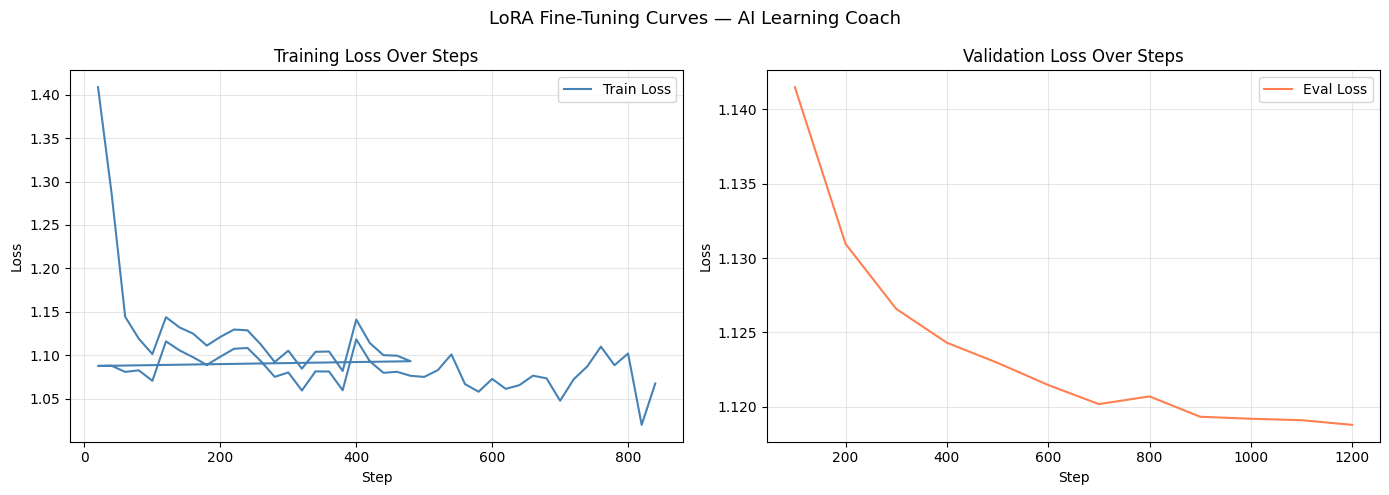

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(loss_tracker.steps, loss_tracker.train_losses, color="steelblue", label="Train Loss")
ax1.set_title("Training Loss Over Steps")
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(alpha=0.3)

eval_steps_x = [i * 100 for i in range(1, len(loss_tracker.eval_losses) + 1)]
ax2.plot(eval_steps_x, loss_tracker.eval_losses, color="coral", label="Eval Loss")
ax2.set_title("Validation Loss Over Steps")
ax2.set_xlabel("Step")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle("LoRA Fine-Tuning Curves — AI Learning Coach", fontsize=13)
plt.tight_layout()

plt.show()

As we can see, the training loss drastically decreases in the first few training steps 0-200, but from 200-800 steps it fluctuates while still following a general trend of decline in loss. The validation loss, on the other hand, follows a smoother and more consistent decline over steps, showing the improvement of the model and increased accuracy over training.

Save model

In [ ]:

from google.colab import drive
import os


drive.mount('/content/drive')


save_path = "/content/drive/MyDrive/372-Project/models/lora-coach"

if not os.path.exists(save_path):
    os.makedirs(save_path)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model successfully saved to Google Drive at: {save_path}")

Model saved.
Mounted at /content/drive
Model successfully saved to Google Drive at: /content/drive/MyDrive/372-Project/models/lora-coach


Custom generation with temperature sampling

In [ ]:
def generate_response(prompt, temperature=0.7, max_new_tokens=256):
    """Custom generation with temperature sampling."""
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,           # enable sampling
            temperature=temperature,  # controls randomness
            top_p=0.9,                # nucleus sampling
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    # Strip the prompt from output
    return decoded[len(tokenizer.decode(inputs["input_ids"][0], skip_special_tokens=True)):]

# Quick test
test_prompt = """### Instruction:
Explain the concept of gradient descent to a student who is learning for the first time.

### Input:

### Response:"""

print(generate_response(test_prompt))


Gradient descent is a popular algorithm used in machine learning and optimization. It works by finding the direction of least curvature, which is a tangent line to a curve at a given point, towards the point where the curve changes direction. The algorithm starts from an initial guess and iteratively updates the current estimate until it converges or reaches a local minimum. Gradient descent has several advantages over other methods such as stochastic gradient descent (SGD), where the update rule involves averaging gradients. One of the main advantages of gradient descent is its ability to handle non-convex problems, while SGD may not converge on some cases. Additionally, gradient descent can be used in situations where there are no initial estimates or when the data set is large, making it more efficient than other algorithms. In summary, gradient descent is an effective method for finding local minima or maxima in functions that have a smooth curvature, and it is easy to implement i

The output is on topic and grammatically correct, which is good, with display of temperature sampling. However, it's factually imprecise with some incorrect information, such as saying that gradient descent is the direction of least curvature, which is incorrect. This is probably due to the model hallucinating from limited training.

This is our iteration 1 baseline model, and I will implement RAG in the next notebook to improve factual precision and correctness of the outputs to give students accurate information when using this model and reduce hallucinations.

